In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Walmart_Store_sales.csv to Walmart_Store_sales.csv


In [3]:
df = pd.read_csv("Walmart_Store_sales.csv")

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
# Convert Date column into datetime format

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [8]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Create new features from the Date column

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day

In [11]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,5


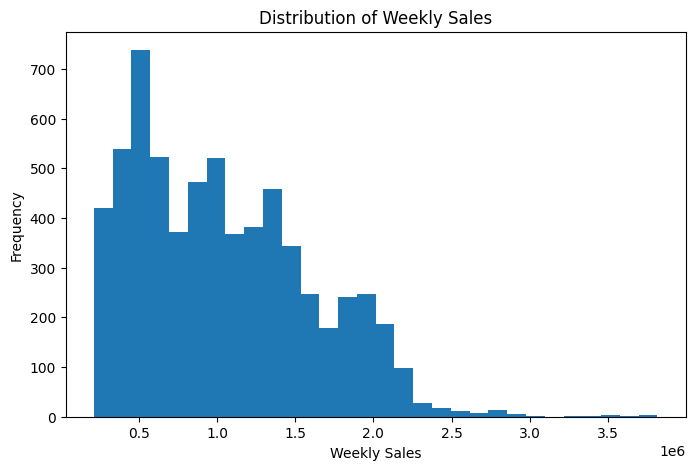

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['Weekly_Sales'], bins=30)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()

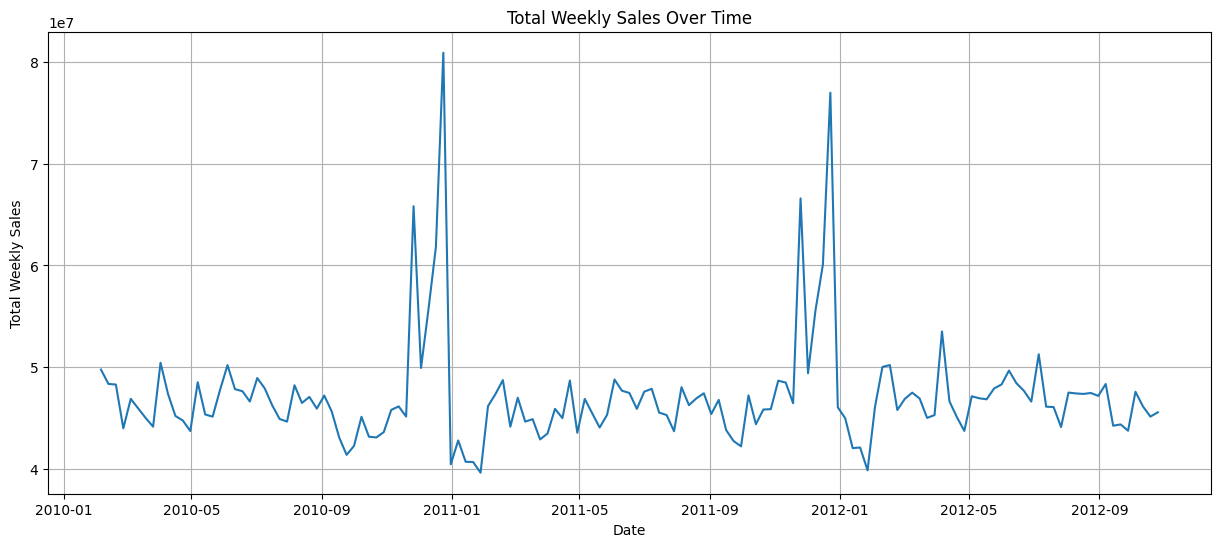

In [16]:
plt.figure(figsize=(15,6))

sales_by_date = df.groupby('Date')['Weekly_Sales'].sum()

plt.plot(sales_by_date.index, sales_by_date.values)

plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')

plt.grid(True)
plt.show()

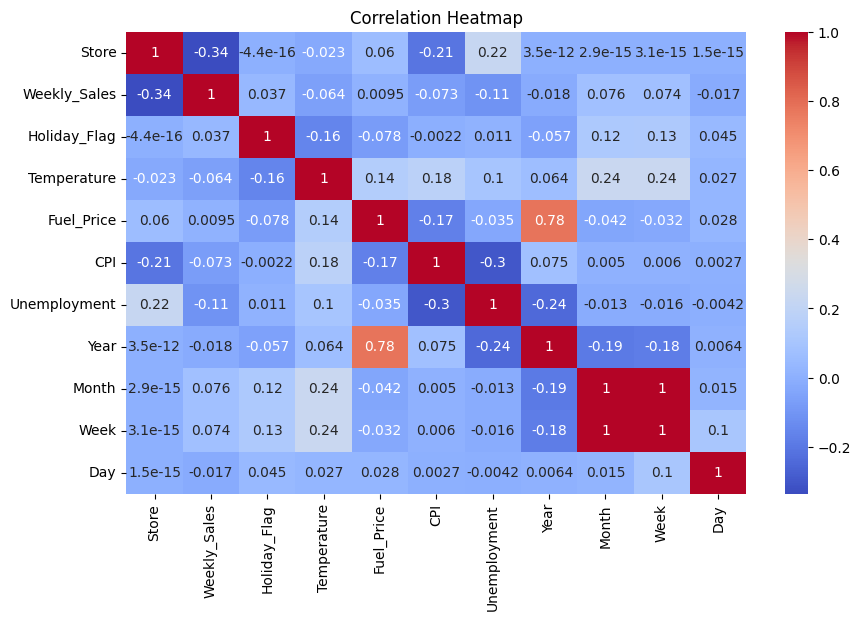

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

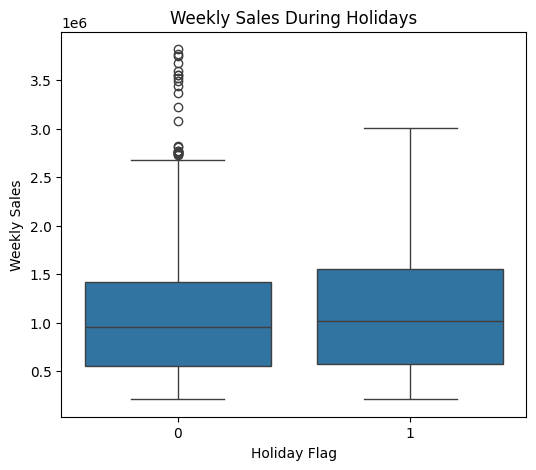

In [15]:
plt.figure(figsize=(6,5))

sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

plt.title('Weekly Sales During Holidays')
plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')

plt.show()

In [17]:
# Select input features

X = df[['Store',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Year',
        'Month',
        'Week',
        'Day']]

# Target variable

y = df['Weekly_Sales']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE : 432598.0289778752
MSE : 272062452501.99554
RMSE: 521596.0625829105
R2 Score: 0.1554909277436093


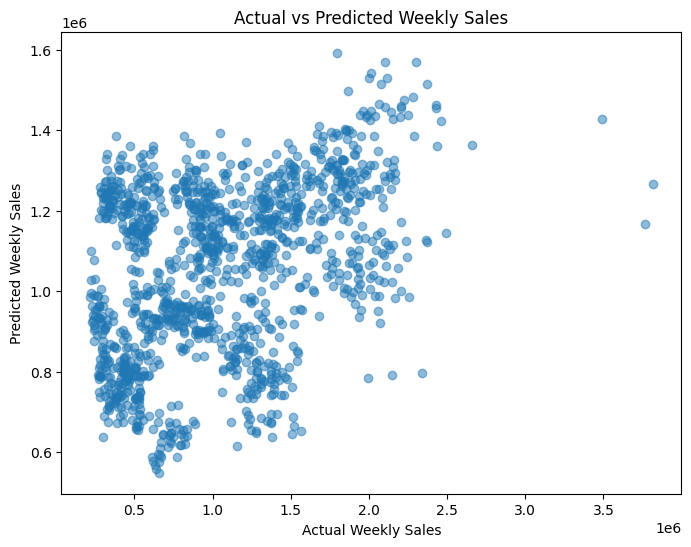

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")

plt.show()

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [24]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE : 53899.132755477855
MSE : 11336001397.66924
RMSE: 106470.65979728519
R2 Score: 0.9648119175012856


In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [27]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [28]:
rf_pred = rf_model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Random Forest Results")
print("----------------------")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score:", r2_score(y_test, rf_pred))

Random Forest Results
----------------------
MAE : 53899.132755477855
MSE : 11336001397.66924
RMSE: 106470.65979728519
R² Score: 0.9648119175012856


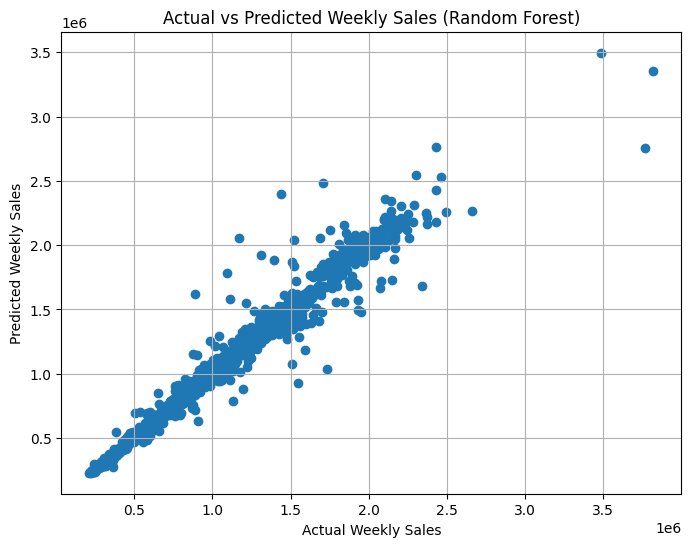

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales (Random Forest)")

plt.grid(True)

plt.show()

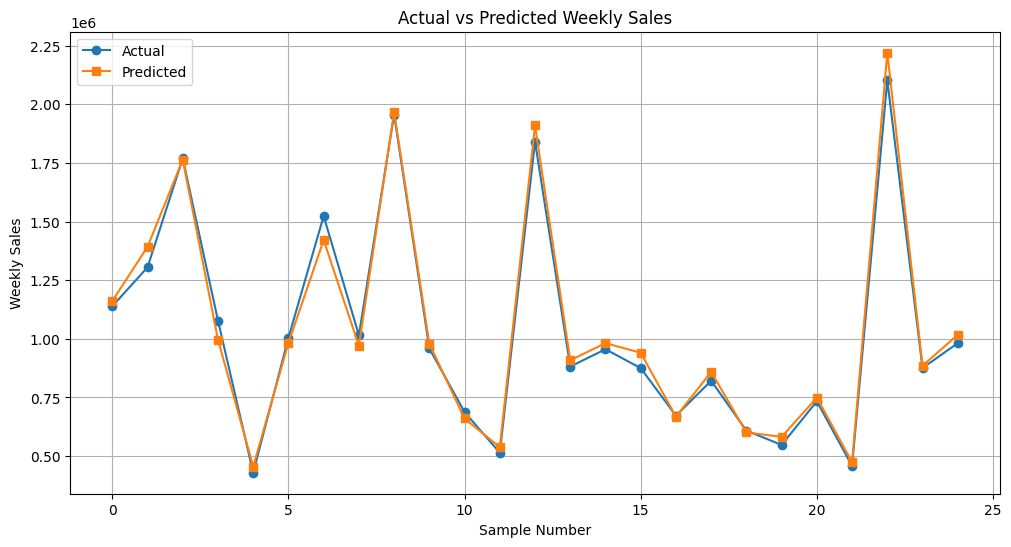

In [31]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

comparison = comparison.head(25)

plt.figure(figsize=(12,6))

plt.plot(comparison["Actual"], marker='o', label="Actual")
plt.plot(comparison["Predicted"], marker='s', label="Predicted")

plt.title("Actual vs Predicted Weekly Sales")

plt.xlabel("Sample Number")
plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
comparison = pd.DataFrame({
    "Actual Weekly Sales": y_test.values,
    "Predicted Weekly Sales": rf_pred
})

comparison.head(20)

,Actual Weekly Sales,Predicted Weekly Sales
0,1138800.32,1.160727e+06
1,1304850.67,1.392198e+06
2,1769296.25,1.763601e+06
3,1077640.13,9.961376e+05
4,428851.99,4.550177e+05
5,1004523.59,9.822684e+05
6,1523410.71,1.421080e+06
7,1014898.78,9.701521e+05
8,1955896.59,1.967418e+06
9,958667.23,9.785187e+05


In [33]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,Store,0.663467
4,CPI,0.151034
5,Unemployment,0.105151
8,Week,0.043828
9,Day,0.011846
2,Temperature,0.011202
3,Fuel_Price,0.008942
7,Month,0.002561
1,Holiday_Flag,0.001056
6,Year,0.000914


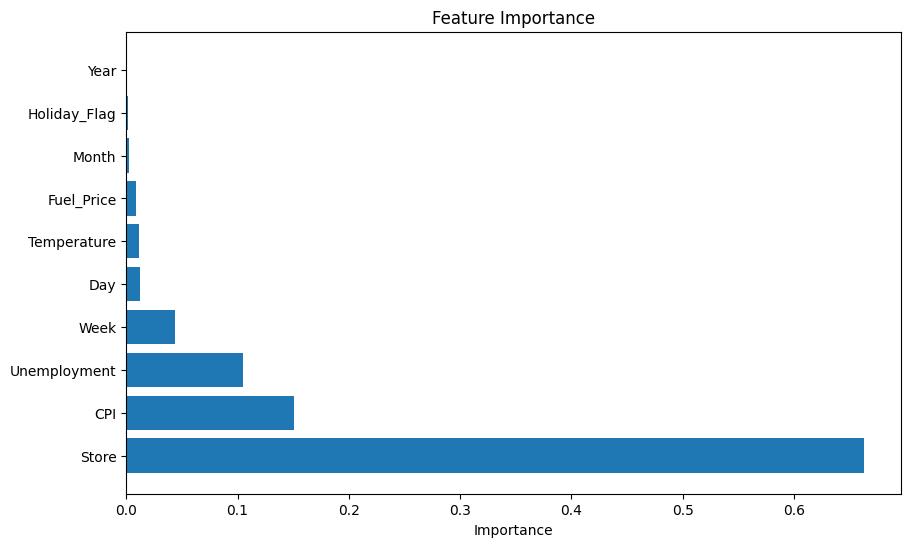

In [34]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()